In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


business_df = pd.read_csv("../data/trustmesh_economic_data.csv")

business_df["month"] = pd.to_datetime(business_df["month"])

print("Dataset shape:", business_df.shape)

Dataset shape: (12000, 32)


In [4]:
print(business_df.columns.tolist())

['business_id', 'owner_id', 'business_type', 'environment_type', 'location', 'month', 'monthly_income', 'monthly_expenses', 'transaction_count', 'digital_payment_pct', 'supplier_payment_amount', 'utility_payment_amount', 'rent_payment', 'savings_amount', 'net_cash_flow', 'payment_discipline_pct', 'supplier_reliability_pct', 'business_continuity_pct', 'demand_stability_pct', 'seasonal_factor', 'seasonally_adjusted_income', 'shock_type', 'shock_factor', 'adjusted_income', 'adjusted_expenses', 'adjusted_cash_flow', 'cash_flow_margin_pct', 'expense_burden_pct', 'operational_stability_pct', 'financial_health_pct', 'resilience_pct', 'economic_reputation_index']


In [5]:
reputation_cols = [
    "financial_health_pct",
    "operational_stability_pct",
    "resilience_pct",
    "payment_discipline_pct",
    "supplier_reliability_pct",
    "business_continuity_pct",
    "demand_stability_pct",
    "digital_payment_pct",
    "cash_flow_margin_pct",
    "expense_burden_pct",
    "economic_reputation_index"
]

display(
    business_df[reputation_cols]
    .corr()["economic_reputation_index"]
    .drop("economic_reputation_index")
    .sort_values(ascending=False)
    .round(3)
)

financial_health_pct         0.840
operational_stability_pct    0.762
cash_flow_margin_pct         0.724
payment_discipline_pct       0.656
resilience_pct               0.612
digital_payment_pct          0.547
business_continuity_pct      0.450
supplier_reliability_pct     0.399
demand_stability_pct         0.375
expense_burden_pct          -0.671
Name: economic_reputation_index, dtype: float64

In [18]:
# Reputation dimensions

business_df["financial_strength_score"] = (
    business_df["financial_health_pct"]
    + business_df["cash_flow_margin_pct"].clip(0, 100)
    + (100 - business_df["expense_burden_pct"].clip(0, 100))
) / 3

business_df["payment_reliability_score"] = (
    business_df["payment_discipline_pct"]
    + business_df["supplier_reliability_pct"]
) / 2

business_df["operational_stability_score"] = (
    business_df["operational_stability_pct"]
    + business_df["business_continuity_pct"]
    + business_df["demand_stability_pct"]
) / 3

business_df["resilience_digital_score"] = (
    business_df["resilience_pct"]
    + business_df["digital_payment_pct"]
) / 2

# Normalize all dimensions to 0–100

dimension_cols = [
    "financial_strength_score",
    "payment_reliability_score",
    "operational_stability_score",
    "resilience_digital_score"
]

for col in dimension_cols:
    business_df[f"{col}_normalized"] = (
        (business_df[col] - business_df[col].min())
        / (business_df[col].max() - business_df[col].min())
        * 100
    )

# Equal-weight reputation score

normalized_cols = [
    f"{col}_normalized" for col in dimension_cols
]

business_df["reputation_score"] = (
    business_df[normalized_cols].mean(axis=1).round(2)
)

print("Reputation framework created successfully.")

Reputation framework created successfully.


In [7]:
dimension_cols = [
    "financial_strength_score",
    "payment_reliability_score",
    "operational_stability_score",
    "resilience_digital_score"
]

for col in dimension_cols:
    business_df[f"{col}_normalized"] = (
        (business_df[col] - business_df[col].min())
        / (business_df[col].max() - business_df[col].min())
        * 100
    )

display(
    business_df[
        [f"{col}_normalized" for col in dimension_cols]
    ]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
financial_strength_score_normalized,12000.0,41.13,18.69,0.0,27.46,40.15,53.06,100.0
payment_reliability_score_normalized,12000.0,52.37,13.67,0.0,42.93,52.51,61.64,100.0
operational_stability_score_normalized,12000.0,51.15,15.09,0.0,40.69,51.09,61.89,100.0
resilience_digital_score_normalized,12000.0,46.39,17.24,0.0,33.43,44.61,57.68,100.0


In [8]:
normalized_cols = [
    f"{col}_normalized" for col in dimension_cols
]

business_df["reputation_score"] = (
    business_df[normalized_cols]
    .mean(axis=1)
    .round(2)
)

display(
    business_df[
        ["business_id", "month", "reputation_score"]
    ].head()
)

print(
    business_df["reputation_score"]
    .describe()
    .round(2)
)

,business_id,month,reputation_score
0,B001,2024-01-01,33.35
1,B001,2024-02-01,42.18
2,B001,2024-03-01,34.54
3,B001,2024-04-01,46.90
4,B001,2024-05-01,44.53


count    12000.00
mean        47.76
std         11.90
min         16.31
25%         39.29
50%         46.47
75%         54.59
max         89.92
Name: reputation_score, dtype: float64


In [9]:
validation = business_df[
    ["economic_reputation_index", "reputation_score"]
].corr().iloc[0, 1]

print(f"Correlation with existing reputation index: {validation:.3f}")

display(
    business_df[
        ["economic_reputation_index", "reputation_score"]
    ].describe()
    .round(2)
)

Correlation with existing reputation index: 0.927


,economic_reputation_index,reputation_score
count,12000.00,12000.00
mean,65.03,47.76
std,5.60,11.90
min,48.92,16.31
25%,61.06,39.29
50%,64.50,46.47
75%,68.36,54.59
max,85.87,89.92


In [10]:
business_reputation = (
    business_df
    .groupby("business_id")
    .agg(
        reputation_score=("reputation_score", "mean"),
        existing_reputation=("economic_reputation_index", "mean")
    )
    .round(2)
)

print("Business profiles:", business_reputation.shape)

display(
    business_reputation
    .sort_values("reputation_score", ascending=False)
    .head(10)
)

Business profiles: (500, 2)


,reputation_score,existing_reputation
business_id,,
B448,73.94,77.05
B104,73.85,76.76
B433,73.59,76.86
B094,73.32,76.07
B123,73.08,76.38
B320,73.01,75.60
B030,72.95,75.84
B475,72.90,75.63
B479,72.72,76.39


In [11]:
rank_validation = business_reputation.assign(
    framework_rank=business_reputation["reputation_score"].rank(
        ascending=False
    ),
    existing_rank=business_reputation["existing_reputation"].rank(
        ascending=False
    )
)

print(
    "Rank correlation:",
    rank_validation[
        ["framework_rank", "existing_rank"]
    ].corr().iloc[0, 1].round(3)
)

Rank correlation: 0.958


In [12]:
framework_summary = pd.DataFrame({
    "dimension": [
        "Financial Strength",
        "Payment Reliability",
        "Operational Stability",
        "Resilience & Digitalization"
    ],
    "weight": [25, 25, 25, 25],
    "components": [
        "Financial health, cash-flow margin, expense burden",
        "Payment discipline, supplier reliability",
        "Operational stability, business continuity, demand stability",
        "Resilience, digital payment strength"
    ]
})

display(framework_summary)

,dimension,weight,components
0,Financial Strength,25,"Financial health, cash-flow margin, expense bu..."
1,Payment Reliability,25,"Payment discipline, supplier reliability"
2,Operational Stability,25,"Operational stability, business continuity, de..."
3,Resilience & Digitalization,25,"Resilience, digital payment strength"


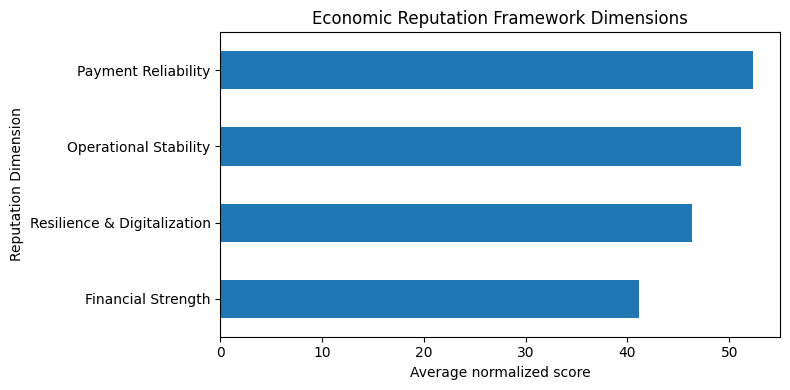

In [19]:
dimension_means = (
    business_df[normalized_cols]
    .mean()
    .rename({
        "financial_strength_score_normalized": "Financial Strength",
        "payment_reliability_score_normalized": "Payment Reliability",
        "operational_stability_score_normalized": "Operational Stability",
        "resilience_digital_score_normalized": "Resilience & Digitalization"
    })
    .sort_values()
)

dimension_means.plot(
    kind="barh",
    figsize=(8, 4),
    legend=False
)

plt.xlabel("Average normalized score")
plt.ylabel("Reputation Dimension")
plt.title("Economic Reputation Framework Dimensions")
plt.tight_layout()
plt.show()

## Economic Reputation Framework

The Economic Reputation Framework evaluates businesses across four core dimensions:

- **Financial Strength (25%)** — financial health, cash-flow margin, and expense burden
- **Payment Reliability (25%)** — payment discipline and supplier reliability
- **Operational Stability (25%)** — operational stability, business continuity, and demand stability
- **Resilience & Digitalization (25%)** — resilience and digital payment strength

Each dimension is normalized to a 0–100 scale before calculating the final reputation score using equal weights.

### Framework Validation

The proposed reputation score was compared with the existing economic reputation index:

- Score correlation: **0.927**
- Business rank correlation: **0.958**

The strong alignment indicates that the proposed framework captures the major patterns represented by the existing reputation index while providing a more transparent, interpretable structure based on distinct economic dimensions.